# Chapter 10 — Noise Reduction & Signal Enhancement

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch10_noise_reduction.ipynb) [![nbviewer](https://img.shields.io/badge/view-nbviewer-orange)](https://nbviewer.org/github/farhad-abtahi/CM2013/blob/main/notebooks/ch10_noise_reduction.ipynb) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch10_noise_reduction.ipynb)

> **Motivating question.** When a filter can't separate signal from noise because they overlap in frequency, what else works?

## What this notebook demonstrates

- Ensemble averaging and the √N SNR law
- Adaptive filtering (LMS) with a reference channel
- Wavelet-threshold denoising
- ICA / PCA for artifact removal
- Matching the enhancement to the noise type

## Runs in

| Platform | Status |
|---|---|
| **nbviewer / GitHub** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
import pywt

CH = 10


def lms(d, x, mu=0.01, order=8):
    """Simple LMS adaptive filter. Returns (y_hat, error, weights)."""
    n = len(d)
    w = np.zeros(order)
    y = np.zeros(n)
    e = np.zeros(n)
    xbuf = np.zeros(order)
    for i in range(n):
        xbuf[1:] = xbuf[:-1]
        xbuf[0] = x[i]
        y[i] = np.dot(w, xbuf)
        e[i] = d[i] - y[i]
        w += 2 * mu * e[i] * xbuf
    return y, e, w

## 10.1  ensemble sqrtN

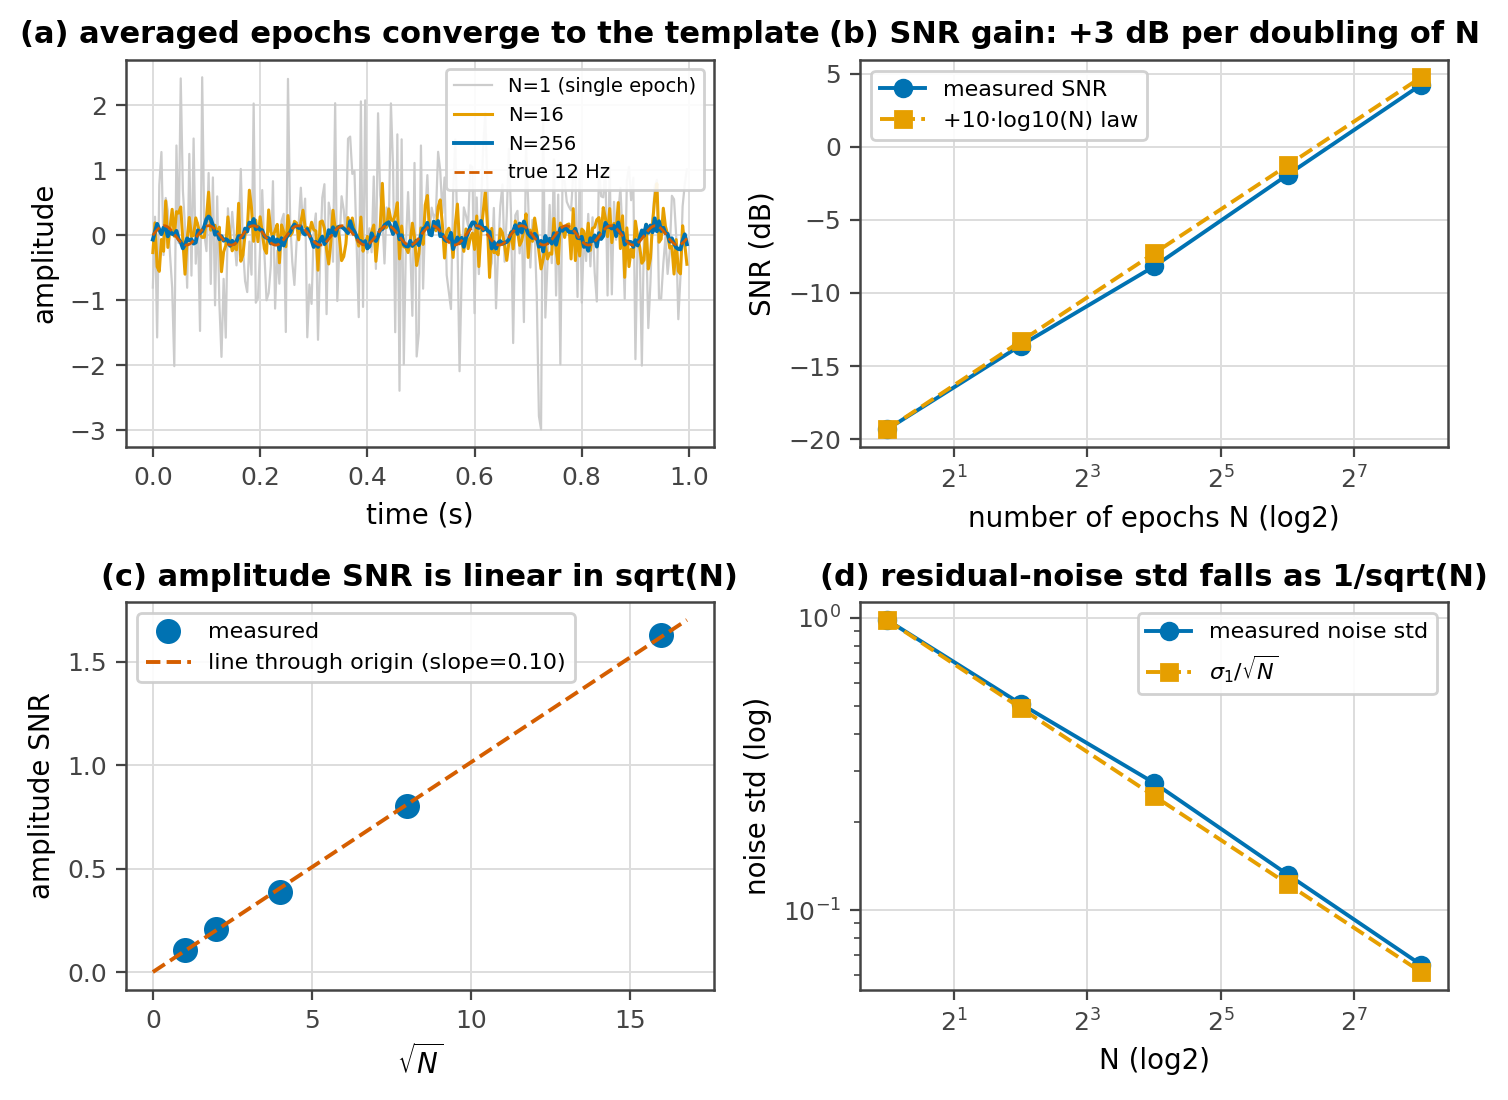

In [3]:
t, epochs, clean = bio.ssvep_epochs(n_epochs=256, dur=1.0, fs=250,
                                    f_stim=12.0, snr=0.15)
signal_power = np.mean(clean ** 2)

def snr_db(avg):
    # noise = residual after subtracting the known clean template
    noise = avg - clean
    return 10 * np.log10(signal_power / (np.mean(noise ** 2) + 1e-15))

Ns = [1, 4, 16, 64, 256]
avgs = {N: epochs[:N].mean(axis=0) for N in Ns}
snrs = np.array([snr_db(avgs[N]) for N in Ns])

fig, ax = bs.newfig(w=7.4, h=5.6, nrows=2, ncols=2)

# (a) a few averaged traces
ax[0, 0].plot(t, avgs[1], color=bs.C["lightgrey"], lw=0.8, label="N=1 (single epoch)")
ax[0, 0].plot(t, avgs[16], color=bs.C["orange"], lw=1.1, label="N=16")
ax[0, 0].plot(t, avgs[256], color=bs.C["blue"], lw=1.4, label="N=256")
ax[0, 0].plot(t, clean, color=bs.C["red"], lw=1.0, ls="--", label="true 12 Hz")
ax[0, 0].set_title("(a) averaged epochs converge to the template")
ax[0, 0].set_xlabel("time (s)")
ax[0, 0].set_ylabel("amplitude")
ax[0, 0].legend(loc="upper right", fontsize=7)

# (b) SNR (dB) vs N with the +3 dB per doubling law
ax[0, 1].plot(Ns, snrs, "o-", color=bs.C["blue"], label="measured SNR")
# theory line anchored at N=1: +10log10(N) dB
theory = snrs[0] + 10 * np.log10(np.array(Ns) / Ns[0])
ax[0, 1].plot(Ns, theory, "s--", color=bs.C["orange"], label="+10·log10(N) law")
ax[0, 1].set_xscale("log", base=2)
ax[0, 1].set_title("(b) SNR gain: +3 dB per doubling of N")
ax[0, 1].set_xlabel("number of epochs N (log2)")
ax[0, 1].set_ylabel("SNR (dB)")
ax[0, 1].legend(loc="upper left", fontsize=8)

# (c) linear SNR (amplitude) vs sqrt(N) — should be a straight line
lin_snr = 10 ** (snrs / 20)          # amplitude-domain SNR
sqrtN = np.sqrt(Ns)
ax[1, 0].plot(sqrtN, lin_snr, "o", color=bs.C["blue"], ms=8, label="measured")
# fit a line through origin
slope = np.sum(sqrtN * lin_snr) / np.sum(sqrtN ** 2)
xx = np.linspace(0, sqrtN.max() * 1.05, 50)
ax[1, 0].plot(xx, slope * xx, "--", color=bs.C["red"],
              label=f"line through origin (slope={slope:.2f})")
ax[1, 0].set_title("(c) amplitude SNR is linear in sqrt(N)")
ax[1, 0].set_xlabel(r"$\sqrt{N}$")
ax[1, 0].set_ylabel("amplitude SNR")
ax[1, 0].legend(loc="upper left", fontsize=8)

# (d) noise std shrinks like 1/sqrt(N)
stds = np.array([np.std(avgs[N] - clean) for N in Ns])
ax[1, 1].plot(Ns, stds, "o-", color=bs.C["blue"], label="measured noise std")
ax[1, 1].plot(Ns, stds[0] / np.sqrt(np.array(Ns) / Ns[0]), "s--",
              color=bs.C["orange"], label=r"$\sigma_1/\sqrt{N}$")
ax[1, 1].set_xscale("log", base=2)
ax[1, 1].set_yscale("log")
ax[1, 1].set_title("(d) residual-noise std falls as 1/sqrt(N)")
ax[1, 1].set_xlabel("N (log2)")
ax[1, 1].set_ylabel("noise std (log)")
ax[1, 1].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 10.2  lms cancellation

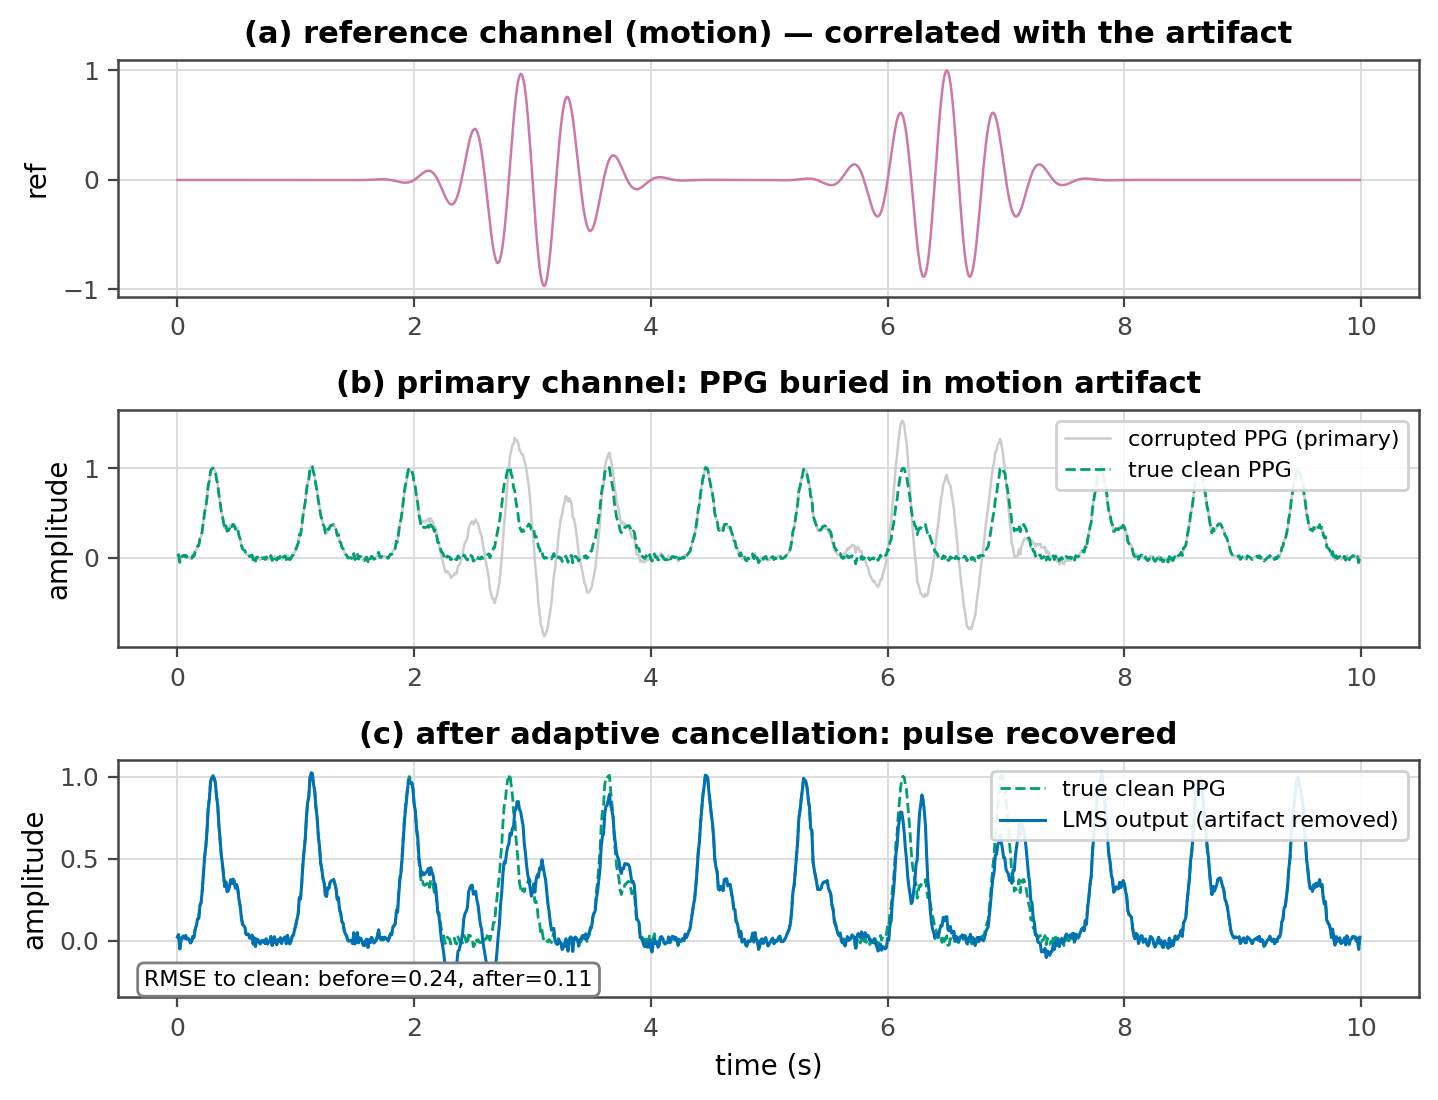

In [4]:
t, x, ref = bio.ppg(duration=10.0, fs=100, hr=72, motion=True)
_, clean, _ = bio.ppg(duration=10.0, fs=100, hr=72, motion=False)

# d = corrupted PPG (primary), ref = correlated motion (reference channel)
y_hat, e, w = lms(x, ref, mu=0.02, order=12)   # e = cleaned estimate

fig, ax = bs.newfig(w=7.4, h=5.6, nrows=3, ncols=1)
ax[0].plot(t, ref, color=bs.C["purple"], lw=0.9)
ax[0].set_title("(a) reference channel (motion) — correlated with the artifact")
ax[0].set_ylabel("ref")

ax[1].plot(t, x, color=bs.C["lightgrey"], lw=0.9, label="corrupted PPG (primary)")
ax[1].plot(t, clean, color=bs.C["green"], lw=1.0, ls="--", label="true clean PPG")
ax[1].set_title("(b) primary channel: PPG buried in motion artifact")
ax[1].set_ylabel("amplitude")
ax[1].legend(loc="upper right", fontsize=8)

ax[2].plot(t, clean, color=bs.C["green"], lw=1.0, ls="--", label="true clean PPG")
ax[2].plot(t, e, color=bs.C["blue"], lw=1.1, label="LMS output (artifact removed)")
ax[2].set_title("(c) after adaptive cancellation: pulse recovered")
ax[2].set_ylabel("amplitude")
ax[2].set_xlabel("time (s)")
ax[2].legend(loc="upper right", fontsize=8)

# annotate improvement
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))
before = rmse(x, clean)
after = rmse(e, clean)
ax[2].text(0.02, 0.05,
           f"RMSE to clean: before={before:.2f}, after={after:.2f}",
           transform=ax[2].transAxes, fontsize=8,
           bbox=dict(boxstyle="round", fc="white", ec=bs.C["grey"]))
plt.tight_layout()
plt.show()

## 10.3  wavelet denoise

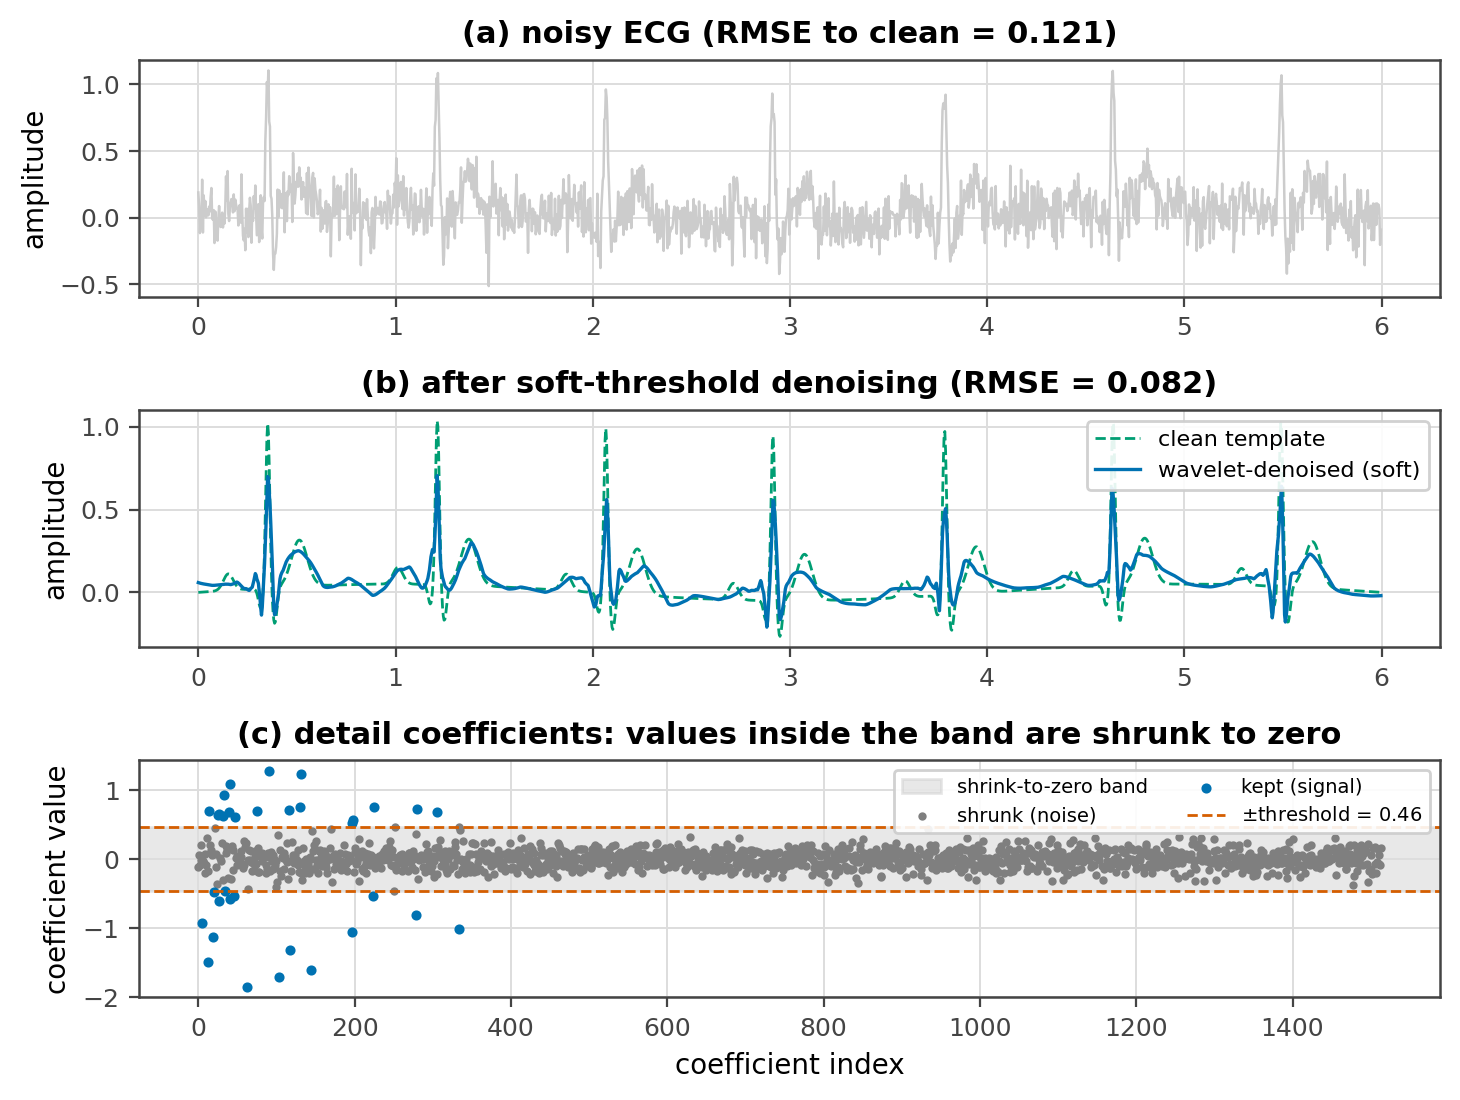

In [5]:
t, x = bio.ecg(duration=6.0, fs=256, noise=0.0)   # near-clean template
rng = np.random.default_rng(30)
noise = 0.12 * rng.standard_normal(len(x))
xn = x + noise

# decompose, universal threshold, soft-threshold, reconstruct
wav = "sym4"
coeffs = pywt.wavedec(xn, wav, level=5)
# robust noise estimate from finest detail (MAD)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
uthresh = sigma * np.sqrt(2 * np.log(len(xn)))
denoised_coeffs = [coeffs[0]] + [
    pywt.threshold(c, uthresh, mode="soft") for c in coeffs[1:]]
x_dn = pywt.waverec(denoised_coeffs, wav)[:len(xn)]

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

fig, ax = bs.newfig(w=7.4, h=5.6, nrows=3, ncols=1)
ax[0].plot(t, xn, color=bs.C["lightgrey"], lw=0.9)
ax[0].set_title(f"(a) noisy ECG (RMSE to clean = {rmse(xn, x):.3f})")
ax[0].set_ylabel("amplitude")

ax[1].plot(t, x, color=bs.C["green"], lw=1.0, ls="--", label="clean template")
ax[1].plot(t, x_dn, color=bs.C["blue"], lw=1.2, label="wavelet-denoised (soft)")
ax[1].set_title(f"(b) after soft-threshold denoising "
                f"(RMSE = {rmse(x_dn, x):.3f})")
ax[1].set_ylabel("amplitude")
ax[1].legend(loc="upper right", fontsize=8)

# coefficient VIEW (toolbox convention): coefficient VALUE on the y-axis,
# coefficient index on the x-axis; the +/- threshold as horizontal lines.
all_details = np.concatenate(coeffs[1:])
idx = np.arange(len(all_details))
kept = np.abs(all_details) >= uthresh
ax[2].axhspan(-uthresh, uthresh, color=bs.C["lightgrey"], alpha=0.45, zorder=0,
              label="shrink-to-zero band")
ax[2].scatter(idx[~kept], all_details[~kept], s=4, color=bs.C["grey"],
              label="shrunk (noise)")
ax[2].scatter(idx[kept], all_details[kept], s=7, color=bs.C["blue"],
              label="kept (signal)")
ax[2].axhline(uthresh, color=bs.C["red"], ls="--", lw=1)
ax[2].axhline(-uthresh, color=bs.C["red"], ls="--", lw=1,
              label=fr"$\pm$threshold = {uthresh:.2f}")
ax[2].set_title("(c) detail coefficients: values inside the band are shrunk to zero")
ax[2].set_xlabel("coefficient index")
ax[2].set_ylabel("coefficient value")
ax[2].legend(loc="upper right", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above and the numbers below *exactly* — the cell below **asserts** them with `expect_close`, so a broken environment is flagged rather than failing silently.

In [6]:
from bsp.metrics import (alias_frequency, quantization_snr_db, sqrtN_gain_db,
                         snr_db, cohens_kappa, macro_f1)
from bsp.notebook_checks import expect_close, expected_output_table
from IPython.display import Markdown, display
_rows = []
_rows.append(expect_close('ensemble-averaging gain at N=100 (dB)', sqrtN_gain_db(100), 20.0, 0.1, 'abs'))
_rows.append(expect_close('gain per doubling of N (dB)', sqrtN_gain_db(2), 3.01, 0.05, 'abs'))
display(Markdown(expected_output_table(_rows)))

[PASS] ensemble-averaging gain at N=100 (dB): got 20, expected 20 (abs)
[PASS] gain per doubling of N (dB): got 3.01, expected 3.01 (abs)


| Quantity | Got | Expected | Status |
|---|---:|---:|:--:|
| ensemble-averaging gain at N=100 (dB) | 20 | 20 | ✅ |
| gain per doubling of N (dB) | 3.01 | 3.01 | ✅ |

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `lms` (DSP toolbox); `wdenoise(x)`; `rica`/`pca`.

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Average N=1,4,16,64,256 epochs and plot measured SNR against √N.

<details><summary>💡 Hint &amp; what you should see</summary>

SNR gain = 10·log10(N) → **+3 dB per doubling**, **+20 dB at N=100**. The measured points fall on the √N line: coherent signal adds linearly, incoherent noise as √N.

</details>

**2.** Cancel a reference-correlated motion artifact from PPG with LMS.

<details><summary>💡 Hint &amp; what you should see</summary>

LMS adapts weights to subtract the part of the PPG **correlated with the reference** (e.g. an accelerometer). It works only when the reference tracks the **artifact** but not the signal.

</details>

In [7]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch10_figures.py`.*